# Do mass-layoff announcements warn you before the market falls? 🪓
### The Challenger job-cut report as a stock-market crystal ball, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Early_warning%3F: Not_supported](https://img.shields.io/badge/Early_warning%3F-Not_supported-8b949e?style=flat-square)

On the first Thursday of every month, an outplacement firm called **Challenger, Gray & Christmas** publishes how many layoffs U.S. employers just **announced**. When that number **spikes**, the folklore says the economy is rolling over and a **stock-market downturn is coming** — layoffs *lead*, the story goes, so a cut-spike is your early-warning to get defensive.

It's a great story. It's also testable. This notebook asks three blunt questions: when job cuts spike, does the market really do worse? Does the cut-spike actually come **first** (that's the whole pitch)? And if you *sold* every time layoffs spiked, would you make money?

> 📓 **Plain-language layer.** Want the *t*-stats, the HAC errors, the lead/lag cross-correlation and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Challenger's series is proprietary — there's no free feed — so we use a hardcoded, **clearly-labelled approximate** monthly reconstruction of the published headline totals (including the giant COVID-2020 record spike). It's a faithful-in-shape *proxy*, not the exact revised vintage. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from challenger_layoffs import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("SPY cache present:", HAVE_REAL,
      "| cuts+SPY months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-31', 'end': '2026-06-30', 'months': 318, 'years': 26.4, 'spike_freq': 41, 'h1': (1, 131, 0.25, 1.16, 0.78, 44, 36, -1.05, -1.66, 0.081), 'h3': (3, 131, 1.7, 2.75, 2.31, 33, 31, -0.73, -0.85, 0.174), 'h6': (6, 131, 3.54, 5.5, 4.67, 33, 27, -0.88, -0.98, 0.12), 'h12': (12, 130, 8.57, 10.63, 9.75, 25, 22, -0.58, -0.61, 0.211), 'leadlag': {-6: -0.099, -5: -0.039, -4: -0.083, -3: -0.236, -2: -0.246, -1: -0.047, 0: 0.015, 1: 0.016, 2: 0.079, 3: 0.088, 4: -0.054, 5: -0.018, 6: 0.056}, 'overlay': (9.3, 0.61, 5.7, 0.55, 5.3, 0.51, 102), 'robust': [('w=6', 139, 7.4, 9.8, -1.25, -1.56, 0.049), ('w=12', 130, 8.6, 9.8, -0.58, -0.61, 0.211), ('w=24', 121, 9.5, 9.8, -0.14, -0.11, 0.421), ('thr>+50%', 34, 13.5, 9.8, 0.98, 0.67, 0.908), ('ex-COVID', 121, 8.7, 10.7, -0.89, -1.03, 0.116)], 'syn': [(0.0, 119, 0.44, 0.66, -0.53, -0.76, 0.277), (0.04, 119, -2.87, -0.65, -5.44, -7.84, 0.001)]}


SPY cache present: True | cuts+SPY months: 318


## The answer first

| Question | Answer |
|---|---|
| When cuts spike, does the market do worse? | **A little — yes.** In the month right after a cut-spike, SPY averages **+0.25%** vs **+0.78%** normally, and falls more often (**44%** vs **36%** of the time). The *direction* matches the folklore. |
| Is that gap reliable? | **No.** It's small and well inside the noise — statistically you can't tell it from luck (and it vanishes if you tweak the recipe). |
| Does the cut-spike come *first*? | **No — and this is the killer.** The layoff signal lines up best with a market move that already happened **two months earlier.** Announcements *follow* stocks here; they don't lead them. |
| So could you trade it? | **It loses.** "Sell when cuts spike" earned **+5.3%/yr** vs **+9.3%** for just holding — you give up return for protection that never shows up. |

> Layoffs and recessions are real. But "layoffs warn you *early*" is a coincident echo wearing a crystal-ball costume — and acting on it costs you money.

## 1 · The claim

> *"Announced job cuts are a leading indicator. When Challenger's monthly number spikes, the labour market is weakening and the stock market is about to follow — so get defensive the moment layoffs surge."*

There's a respectable backbone to this: the Challenger report lands *before* the official government jobs number and counts *announcements* — forward-looking intentions, not backward-looking headcounts. So the intuition isn't crazy — fewer jobs, weaker spending, lower profits. The trading leap is the part we test: that a cut *spike* arrives early enough, and cleanly enough, to be a **tradable** warning for equities.

## 2 · So what?

If true, this would be gold: a free, monthly, widely-reported number that tells you to step aside before drawdowns. But "leading" hides a trap. The **stock market is itself a leading indicator** — it usually turns *before* the economy. So a labour number that lines up with market weakness might not be *predicting* the market at all; it might just be **echoing** a turn the market already made. The difference between *leads* and *echoes* is the difference between an edge and a mirage — and you can only tell them apart by checking the timing carefully.

## 3 · How would we even know?

We line up **26 years** (2000–2026, 318 months) of Challenger's monthly job-cut number against month-end SPY, and:

1. **Split the months.** Call cuts **spiking** when the month runs above its own trailing-year average. Compare what SPY did next (1/3/6/12 months) in spike months vs all months. Crucially, we only ever act **after** the report is public — a strict one-month release lag, no peeking.
2. **Check the timing.** The crucial test: slide the layoff signal forward and backward against the market and find *where* they line up best. If layoffs truly **lead**, the strongest link shows up at a **positive lead** (cuts first, market later).
3. **Try to trade it.** Sit in cash whenever cuts spike, hold otherwise, pay realistic costs — and see if it beats just buying and holding.

## 4 · The teardown — let's actually look

**First, the raw material.** Here's the monthly job-cut number over a quarter-century — the quiet stretches, and the giant spikes (2001, 2008–09, and the off-the-chart COVID surge of 2020). Layoffs clearly *know* about recessions. The question is whether they know **early**.

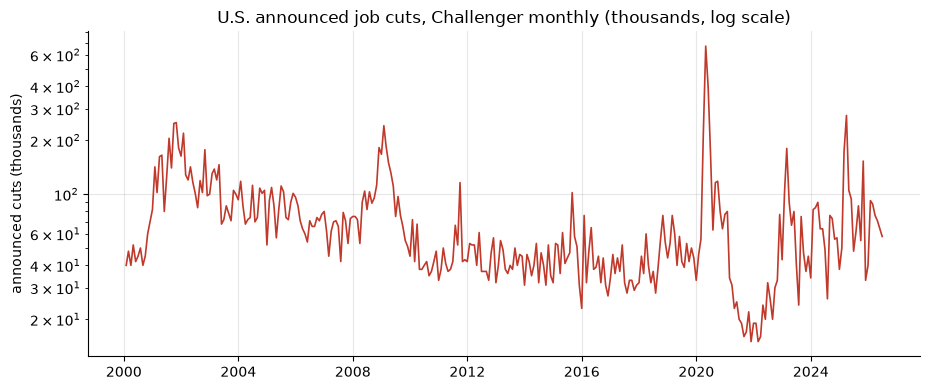

peak month: 671 thousand announced, around 2020-04-30


In [2]:
if HAVE_REAL:
    x = F['cuts']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(x.index, x.values, c=RED, lw=1.2)
    ax.set_yscale('log')
    ax.set_title('U.S. announced job cuts, Challenger monthly (thousands, log scale)')
    ax.set_ylabel('announced cuts (thousands)')
    plt.tight_layout(); plt.show()
    print('peak month:', int(x.max()), 'thousand announced, around', x.idxmax().date())
else:
    print('no cache — see docs/results.md; COVID spike ~671k announced in Apr 2020')

**Now the payoff.** For each horizon, the average forward SPY return in **spike** months next to the return on an **average** month. The folklore predicts the green bars sit *below* the grey ones.

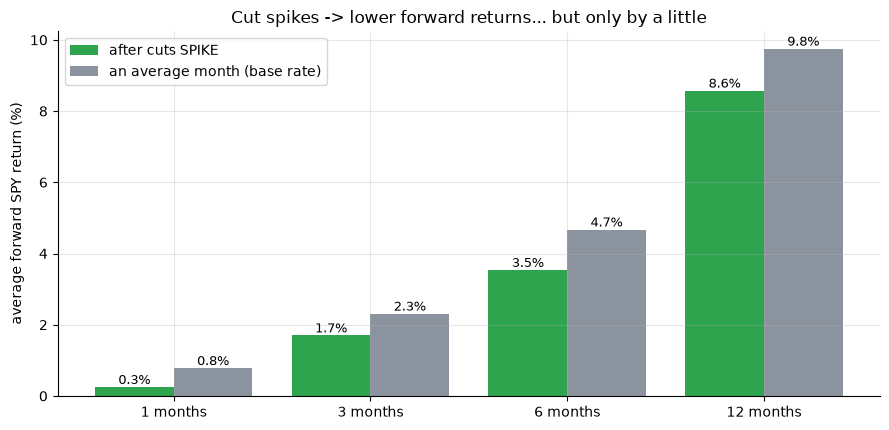

1-month: spike 0.25% vs base 0.78%


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(F, m) for m in hs]
    spk = [r['spike_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    spk = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    base = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
xx = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(xx-.2, spk, .4, color=GREEN, label='after cuts SPIKE')
ax.bar(xx+.2, base, .4, color=GREY, label='an average month (base rate)')
ax.set_xticks(xx); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('average forward SPY return (%)')
ax.set_title('Cut spikes -> lower forward returns... but only by a little')
for i,(a,b) in enumerate(zip(spk,base)):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('1-month: spike', f'{spk[0]:.2f}%', 'vs base', f'{base[0]:.2f}%')

The direction is right — the gap is biggest in the **month right after the print** (**+0.25%** after a spike vs **+0.78%** normally, and the market is *down* **44%** of the time vs **36%**). That's the "announcement-drift" everyone points to. But the gap is small — small enough that, with the numbers we have, it could easily be chance — and it *shrinks* as you look further out. Hold that thought; the *next* chart is where the story breaks.

**The crucial test: does the cut-spike come *first*?** We slide the layoff signal forward and backward against the market and measure how tightly they move together. A real early-warning would show its strongest *downward* link at a **positive lead** (cuts lead → bar dips on the right). Watch where it actually dips.

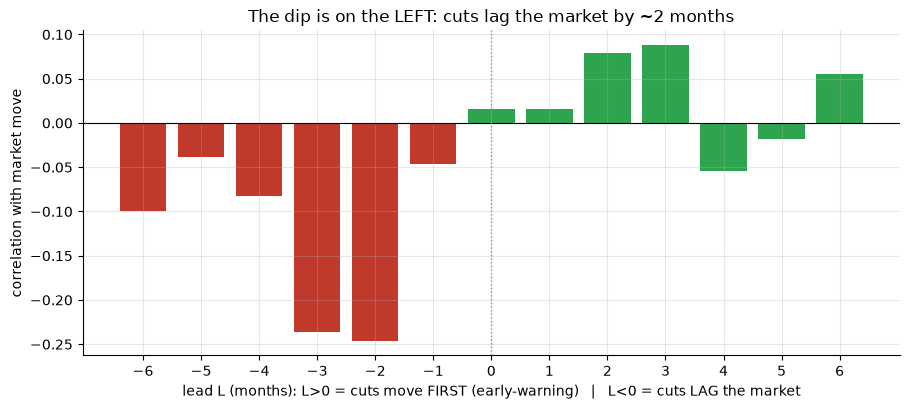

strongest negative link at L=-2 months (cuts FOLLOW the market here)


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F)
    Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [RED if L<0 else GREEN for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
ax.set_xlabel('lead L (months): L>0 = cuts move FIRST (early-warning)   |   L<0 = cuts LAG the market')
ax.set_ylabel('correlation with market move'); ax.set_xticks(Ls)
ax.set_title('The dip is on the LEFT: cuts lag the market by ~2 months')
plt.tight_layout(); plt.show()
imin = int(np.nanargmin(cs))
print(f'strongest negative link at L={Ls[imin]} months (cuts FOLLOW the market here)')

There it is. The deepest *negative* bar is at **L = −2** — the layoff signal lines up best with a market move that happened **two months earlier**. On the right, where a true early-warning would live (cuts moving first), the bars are near zero or even *positive*. **Layoff announcements aren't leading the market — they're trailing it.** The recession shows up in stock prices, and only later in the layoff count.

**Could you trade it anyway?** Suppose you sold (went to cash) every month cuts were spiking and held SPY otherwise. Here's that strategy's growth vs just buying and holding.

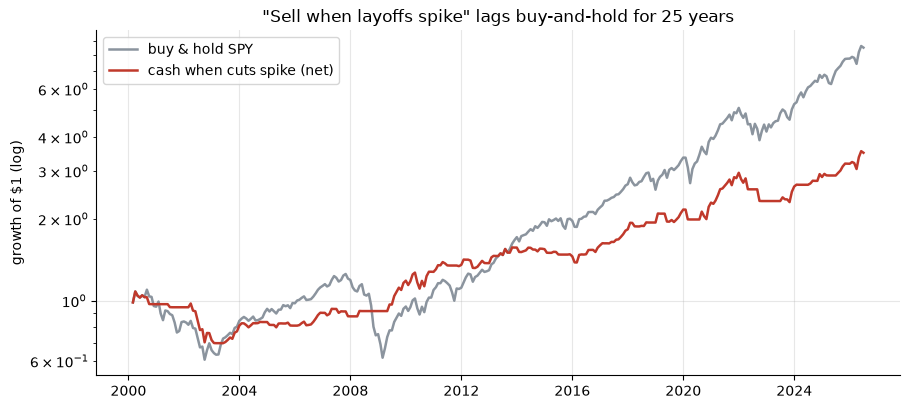

final $1 -> buy&hold 8.5x  vs  overlay 3.5x


In [5]:
if HAVE_REAL:
    spike = st.spike_mask(F); pos = (~spike).astype(float).shift(1)
    rr = F['spy'].pct_change()
    import pandas as pd
    dfp = pd.DataFrame({'r': rr, 'pos': pos}).dropna()
    sw = dfp['pos'].diff().abs().fillna(0); cst=10/1e4
    overlay = (dfp['pos']*dfp['r'] - sw*cst)
    bh_grow = (1+dfp['r']).cumprod(); ov_grow = (1+overlay).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(bh_grow.index, bh_grow.values, c=GREY, lw=1.8, label='buy & hold SPY')
    ax.plot(ov_grow.index, ov_grow.values, c=RED, lw=1.8, label='cash when cuts spike (net)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('"Sell when layoffs spike" lags buy-and-hold for 25 years')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final $1 -> buy&hold {bh_grow.iloc[-1]:.1f}x  vs  overlay {ov_grow.iloc[-1]:.1f}x')
else:
    print(f"overlay {R['overlay'][4]:.1f}%/yr vs buy-hold {R['overlay'][0]:.1f}%/yr (net) — see results.md")

The defensive overlay ends up **well below** buy-and-hold — **+5.3%/yr** vs **+9.3%/yr** net, and a *lower* Sharpe (0.51 vs 0.61). Every time you stepped aside on a cut spike you mostly missed *gains*, because layoffs kept spiking well into recoveries the market had already started pricing. The signal doesn't just fail to help — **it hurts.**

## 5 · The verdict

- **Signal — Weak.** A cut spike really does precede slightly weaker, more-often-negative returns — clearest in the announcement-drift month — but the gap is small, not statistically significant, and fragile to how you define the signal. Real as lore, weak as edge.
- **Tradability — Mirage.** Selling on layoff spikes **loses to buy-and-hold**. There's nothing to deploy.
- **Early warning? — Not supported.** The cut spike lines up with a market move that already happened two months earlier. Layoffs **echo** equity weakness; they don't forecast it. The one word that makes the pitch — *early* — is the part the data rejects.

## 6 · Could you actually trade it? — the honest bottom line

Forget significance for a second. Even if the small tilt were real, the operational reality is brutal: cuts run 'above trend' in **roughly four months out of ten** (every bump counts as a spike), so a cash-on-spike rule whipsaws you in and out constantly — **102 switches** in 25 years — while the deepest layoff surges (the *genuine* recession lows) are exactly the moments you'd most want to be **buying**, not selling. That's why pushing the rule to only fire on a *big* cut spike flips its sign **positive**. There is no version of "sell when layoffs spike" that both fires early and makes money.

## 7 · Going further 🚪

- **The sibling test.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) asks the same question of weekly unemployment claims: real labour signal, but can you trade it?
- **The single-stock cousin.** [Study 749 — Layoff-Drift](../749-layoff-drift/) tests whether *one company's* layoff announcement pops or drifts — the micro version of this macro question.
- **Build your own.** Swap the trailing-average spike for a year-over-year jump, or pair cuts with a *price* trend filter — the lead/lag picture barely budges: a coincident series can't be made to lead by redefining the spike.

*Think layoffs lead the market? Show the lead/lag chart dipping on the **right** (positive lead) — then we'll talk.*